# COMP 352 Final Project - Spotify Predictions

### By Cameron McNamara, Bilal Adam, Maximo Babun

Requirements: 
  - There are four sections of the final project. You are expected to perform the following tasks within each section to fulfill the project requirements. Remember data science is cyclical in nature and requires multiple attempts and iterations. It is okay if your code moves between sections as you try different approaches, but at the end please try and organize your code into these sections for grading purposes.
- Data Importing and Pre-processing (100 Points)
  - Import dataset and describe characteristics such as dimensions, data types, file types, and import methods used
  - Clean, wrangle, and handle missing data, duplicate data, etc.
  - Encode any categorical variables
  - Perform feature engineering on the dataset
  - Transform data appropriately using techniques such as aggregation, normalization, and feature construction
  - Reduce redundant data and perform need based discretization
- Data Analysis and Visualization (100 Points)
  - Identify categorical, ordinal, and numerical variables within data
  - Provide measures of centrality and distribution with visualizations
  - Diagnose for correlations between variables and determine independent and dependent variables
  - Perform exploratory analysis in combination with visualization techniques to discover patterns and features of interest
  - Create visualizations that allow for the discovery of insights in the data

- Data Analytics (100 Points)
  - Determine the need for a supervised or unsupervised learning method and identify dependent and independent variables
  - Choose and provide reasoning for the selected metric or metrics employed to assess your model.
  - Train, test, cross validate, and provide performance metrics for model results
  - Try multiple different types of algorithms to determine the best model for your dataset
  - Analyze your model performance


First we must setup our environment to make sure we have all appropriate modules installed. To do this, I have provided 2 methods. The 1st, is to install all modules using a ```.yaml``` file via ```conda```. 

To do this, run:
```bash
conda env create -f env_setup/data_environment.yml
```
Then activate the environment by:
```bash
conda activate data_env
```

## Data Importing and Pre-processing <a class="anchor" id="data-importing"></a>

In [61]:
# import libraries needed
import pandas as pd

pd.set_option("display.max_columns", None)
import warnings

import branca
import folium
import geopandas as gpd
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xgboost as xgb
from branca.element import Figure
from folium import Marker
from folium.plugins import HeatMap
from scipy.special import boxcox1p
from scipy.stats import norm, probplot, skew
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from utils.model_utils import (
    time_series_split_regression,
    StackedEnsembleCVRegressor,
)
from utils.metrics_utils import (
    compute_rmse_std,
    print_rmse_and_dates,
)

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas.*")
%matplotlib inline

In [62]:
## Import Data
spotify = pd.read_csv("SpotifyFeatures.csv")

#### Explore Dataset Dimensions

In [63]:
print(spotify.shape)
print("Total Observations:", spotify.shape[0])

(232725, 18)
Total Observations: 232725


In [64]:
cat_count = 0
for dtype in spotify.dtypes:
    if dtype == "object":
        cat_count = cat_count + 1

In [65]:
print("# of categorical variables:", cat_count)

numeric_vars = spotify.shape[1] - cat_count - 1
print("# of continous variables:", numeric_vars)

# of categorical variables: 7
# of continous variables: 10


#### Remove Unecessary Columns

In [66]:
spotify.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [67]:
# Remove Artist_name and track_name - high cardinality providing no predictive power.
spotify = spotify.drop(columns=["artist_name", "track_name"])

#### Check for missing values

In [68]:
total = spotify.isnull().sum().sort_values(ascending=False)
percent = (spotify.isnull().sum() / spotify.isnull().count()).sort_values(
    ascending=False
)
missing_data = pd.concat([total, percent], axis=1, keys=["Total", "Percent"])
missing_data.head(20)

,Total,Percent
genre,0,0.0
track_id,0,0.0
popularity,0,0.0
acousticness,0,0.0
danceability,0,0.0
duration_ms,0,0.0
energy,0,0.0
instrumentalness,0,0.0
key,0,0.0
liveness,0,0.0


In [69]:
# No Missing Values - Moving onto one-hot encoding of categorical variables

#### Check for Duplicate Song IDs

In [70]:
spotify["track_id"].duplicated().sum()

np.int64(55951)

In [71]:
dup_ids = spotify[spotify["track_id"].duplicated(keep=False)]
dup_ids.sort_values("track_id").head(10)


,genre,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
14492,Dance,000xQL6tZNLJzIrtIgxqSl,70,0.1310,0.748,188491,0.6270,0.00000,G,0.0852,-6.029,Major,0.0644,120.963,4/4,0.5240
110840,Pop,000xQL6tZNLJzIrtIgxqSl,70,0.1310,0.748,188491,0.6270,0.00000,G,0.0852,-6.029,Major,0.0644,120.963,4/4,0.5240
96926,Children’s Music,001gDjxhKGDSx4sMMAgS9R,57,0.0349,0.564,211789,0.8080,0.00036,C#,0.3260,-5.825,Major,0.0481,78.439,4/4,0.3650
153533,Rock,001gDjxhKGDSx4sMMAgS9R,58,0.0349,0.564,211789,0.8080,0.00036,C#,0.3260,-5.825,Major,0.0481,78.439,4/4,0.3650
65253,Folk,001ifh9Zkyc5DhK7AGQRtK,42,0.4470,0.411,395573,0.4220,0.12100,E,0.0742,-5.475,Minor,0.0459,147.465,1/4,0.3460
145387,Indie,001ifh9Zkyc5DhK7AGQRtK,42,0.4470,0.411,395573,0.4220,0.12100,E,0.0742,-5.475,Minor,0.0459,147.465,1/4,0.3460
201614,Soundtrack,002PgfoyfrOGiKch4EW8Wm,33,0.9850,0.199,46867,0.0376,0.62800,G#,0.1150,-31.142,Major,0.0457,68.167,4/4,0.0891
182413,Movie,002PgfoyfrOGiKch4EW8Wm,33,0.9850,0.199,46867,0.0376,0.62800,G#,0.1150,-31.142,Major,0.0457,68.167,4/4,0.0891
121130,Rap,002QT7AS6h1LAF5dla8D92,50,0.0469,0.830,207827,0.6530,0.00000,C#,0.1120,-5.298,Major,0.1850,123.032,4/4,0.2280
90714,Hip-Hop,002QT7AS6h1LAF5dla8D92,50,0.0469,0.830,207827,0.6530,0.00000,C#,0.1120,-5.298,Major,0.1850,123.032,4/4,0.2280


In [72]:
genre_dummies = pd.get_dummies(spotify["genre"], prefix="genre")
spotify_with_dummies = pd.concat([spotify, genre_dummies], axis=1)

# Group by track_id, taking max for genre columns (so all applicable genres = 1)
genre_cols = [col for col in spotify_with_dummies.columns if col.startswith("genre_")]

spotify_clean = spotify_with_dummies.groupby("track_id", as_index=False).agg(
    {
        **{
            col: "first"
            for col in spotify.columns
            if col not in ["track_id", "genre", "popularity"]
        },
        **{col: "max" for col in genre_cols},  # Max ensures all genres are captured
        "popularity": "mean",  # or 'max', your choice
    }
)

spotify=spotify_clean

In [73]:
spotify.head()
spotify.shape

(176774, 42)

There are 232,000 different records, however, certain songs appear more than once under different genres. In order to get around these duplicates, we only kept one observation per song id. In order to do this we created a one-hot encoded variables for genre, and aggregated them based on song_id. THis means taht if a song applies to more than one genre, they will have more than one TRUE for the binary encoded genre columns. In this aggregation we took the mean of the popularity of the two columns, if it was differing.

#### One-Hot Encode reamining cateogrical variables

In [74]:
cat_cols = ["key", "time_signature", "mode"]
spotify = pd.get_dummies(
    spotify,
    columns=cat_cols,
    prefix=cat_cols,
    drop_first=True
)

In [75]:
spotify.shape

(176774, 55)

In [76]:
spotify.head()

,track_id,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,genre_A Capella,genre_Alternative,genre_Anime,genre_Blues,genre_Children's Music,genre_Children’s Music,genre_Classical,genre_Comedy,genre_Country,genre_Dance,genre_Electronic,genre_Folk,genre_Hip-Hop,genre_Indie,genre_Jazz,genre_Movie,genre_Opera,genre_Pop,genre_R&B,genre_Rap,genre_Reggae,genre_Reggaeton,genre_Rock,genre_Ska,genre_Soul,genre_Soundtrack,genre_World,popularity,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,time_signature_1/4,time_signature_3/4,time_signature_4/4,time_signature_5/4,mode_Minor
0,00021Wy6AyMbLP2tqij86e,0.234,0.617,169173,0.862,0.976000,0.1410,-12.855,0.0514,129.578,0.886,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,13.0,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False
1,000CzNKC8PEt1yC3L8dqwV,0.249,0.518,130653,0.805,0.000000,0.3330,-6.248,0.0407,79.124,0.841,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,5.0,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False
2,000DfZJww8KiixTKuk9usJ,0.366,0.631,357573,0.513,0.000004,0.1090,-6.376,0.0293,120.365,0.307,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,30.0,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
3,000EWWBkYaREzsBplYjUag,0.815,0.768,104924,0.137,0.922000,0.1130,-13.284,0.0747,76.430,0.560,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,39.0,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True
4,000xQL6tZNLJzIrtIgxqSl,0.131,0.748,188491,0.627,0.000000,0.0852,-6.029,0.0644,120.963,0.524,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,70.0,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False


#### Feature Engineering

In [77]:
spotify["Hit"] = (spotify["popularity"] >= 70).astype(int)

Create Binary "Hit" column, classifying all songs with popularity >= 70 as a hit

In [78]:
spotify["very_loud"] = (spotify["loudness"] > spotify["loudness"].quantile(0.9)).astype(int)
spotify["very_quiet"] = (spotify["loudness"] < spotify["loudness"].quantile(0.1)).astype(int)
spotify["tempo_fast"] = (spotify["tempo"] >= 120).astype(int)
spotify["tempo_slow"] = (spotify["tempo"] <= 90).astype(int)

Create banded very loud, very quiet, fast tempo, adn slow tempo, binary columns to help with hit classifcation. These are often penalized (i.e. very loud songs are not very popular, same with very quiet songs).

In [79]:
spotify["energy_dance"] = spotify["energy"] * spotify["danceability"]

Create an energy * dance feature to represent how danceable and energetic a song is, as many hits are both danceable and energetic

### 2. Data analysis and Visualization


2.1: Identify categorical, ordinal, and numerical variables

In [80]:
numerical_cols = spotify.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = spotify.select_dtypes(include=["object", "bool"]).columns

len(numerical_cols), len(categorical_cols)

(17, 44)

In [81]:
numerical_cols

Index(['acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo',
       'valence', 'popularity', 'Hit', 'very_loud', 'very_quiet', 'tempo_fast',
       'tempo_slow', 'energy_dance'],
      dtype='object')

In [82]:
categorical_cols

Index(['track_id', 'genre_A Capella', 'genre_Alternative', 'genre_Anime',
       'genre_Blues', 'genre_Children's Music', 'genre_Children’s Music',
       'genre_Classical', 'genre_Comedy', 'genre_Country', 'genre_Dance',
       'genre_Electronic', 'genre_Folk', 'genre_Hip-Hop', 'genre_Indie',
       'genre_Jazz', 'genre_Movie', 'genre_Opera', 'genre_Pop', 'genre_R&B',
       'genre_Rap', 'genre_Reggae', 'genre_Reggaeton', 'genre_Rock',
       'genre_Ska', 'genre_Soul', 'genre_Soundtrack', 'genre_World', 'key_A#',
       'key_B', 'key_C', 'key_C#', 'key_D', 'key_D#', 'key_E', 'key_F',
       'key_F#', 'key_G', 'key_G#', 'time_signature_1/4', 'time_signature_3/4',
       'time_signature_4/4', 'time_signature_5/4', 'mode_Minor'],
      dtype='object')

#### Variable Types

- **Numerical variables** include audio features such as popularity, tempo, loudness, energy, danceability, and duration.
- **Categorical variables** include identifiers and encoded genre and musical attributes.
- No ordinal variables are explicitly present in this dataset.

### 2.2 Provide measures of centrality and distribution with visualizations

In [83]:
spotify[numerical_cols].describe()

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,Hit,very_loud,very_quiet,tempo_fast,tempo_slow,energy_dance
count,176774.000000,176774.000000,1.767740e+05,176774.000000,176774.000000,176774.000000,176774.000000,176774.000000,176774.000000,176774.000000,176774.000000,176774.000000,176774.000000,176774.000000,176774.000000,176774.000000,176774.000000
mean,0.404135,0.541068,2.361272e+05,0.557025,0.172073,0.224531,-10.137605,0.127395,117.203679,0.451595,36.417756,0.022170,0.099992,0.100003,0.447447,0.223534,0.320568
std,0.366302,0.190387,1.305132e+05,0.275839,0.322936,0.211027,6.395551,0.204345,31.325091,0.267820,17.505193,0.147235,0.299990,0.300005,0.497232,0.416614,0.189118
min,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000002
25%,0.045600,0.415000,1.782530e+05,0.344000,0.000000,0.097500,-12.851000,0.036800,92.006000,0.222000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.164936
50%,0.288000,0.558000,2.194530e+05,0.592000,0.000070,0.130000,-8.191000,0.049400,115.006500,0.440000,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.338316
75%,0.791000,0.683000,2.685470e+05,0.789000,0.090800,0.277000,-5.631000,0.102000,138.799750,0.667000,49.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.466128
max,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.895856


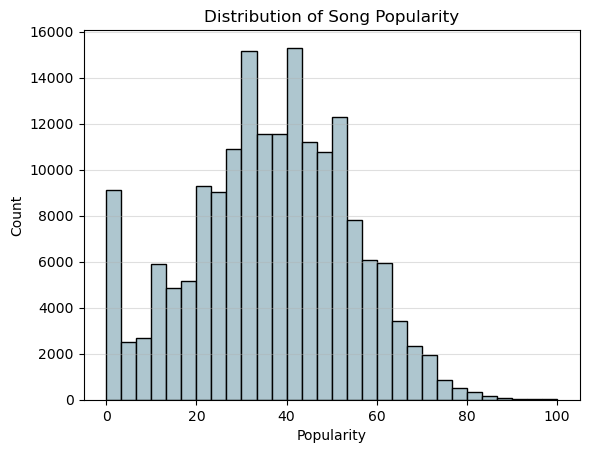

In [84]:
import matplotlib.pyplot as plt

plt.hist(
    spotify["popularity"],
    bins=30,
    color="#AEC6CF",
    edgecolor="black"
)

plt.xlabel("Popularity")
plt.ylabel("Count")
plt.title("Distribution of Song Popularity")
plt.grid(axis="y", alpha=0.4)

plt.show()

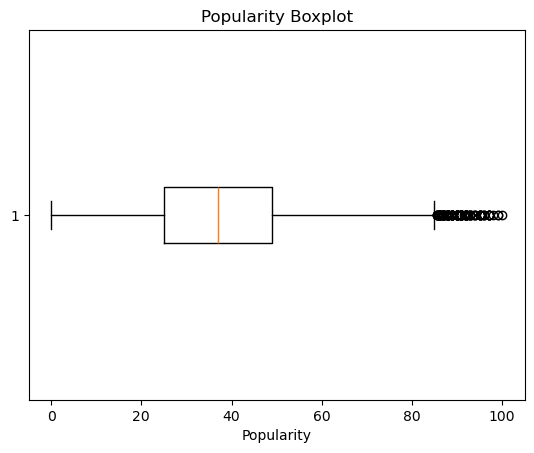

In [85]:
plt.boxplot(spotify["popularity"], vert=False)
plt.xlabel("Popularity")
plt.title("Popularity Boxplot")
plt.show()

The popularity variable is right-skewed, with most songs having lower popularity values.
A small number of songs appear as outliers with very high popularity.

### 2.3: Diagnose for correlations between variables and determine independent and dependent variables

In [86]:
corr_matrix = spotify[numerical_cols].corr()
corr_matrix

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,Hit,very_loud,very_quiet,tempo_fast,tempo_slow,energy_dance
acousticness,1.000000,-0.379018,0.010294,-0.729884,0.305213,0.078869,-0.693157,0.172665,-0.260823,-0.348577,-0.360838,-0.074470,-0.277764,0.454213,-0.204905,0.280951,-0.669312
danceability,-0.379018,1.000000,-0.124258,0.365232,-0.370872,-0.026899,0.460542,0.133137,0.046786,0.587601,0.221062,0.093568,0.045093,-0.415428,0.031222,-0.245856,0.726107
duration_ms,0.010294,-0.124258,1.000000,-0.029969,0.069618,0.023598,-0.042929,-0.011580,-0.030055,-0.146981,0.018911,-0.018636,-0.033860,0.038991,-0.007578,0.029480,-0.065330
energy,-0.729884,0.365232,-0.029969,1.000000,-0.391797,0.210485,0.824522,0.162432,0.241539,0.449565,0.235572,0.048061,0.390463,-0.553591,0.175224,-0.259316,0.857509
instrumentalness,0.305213,-0.370872,0.069618,-0.391797,1.000000,-0.162712,-0.501382,-0.191648,-0.109288,-0.331214,-0.149267,-0.074928,-0.130425,0.406544,-0.072309,0.116529,-0.404778
liveness,0.078869,-0.026899,0.023598,0.210485,-0.162712,1.000000,0.057915,0.555547,-0.062021,0.005851,-0.161978,-0.037797,0.019849,-0.069442,-0.048014,0.074498,0.112080
loudness,-0.693157,0.460542,-0.042929,0.824522,-0.501382,0.057915,1.000000,0.000802,0.246279,0.426938,0.323306,0.085856,0.363294,-0.763549,0.183872,-0.264496,0.746107
speechiness,0.172665,0.133137,-0.011580,0.162432,-0.191648,0.555547,0.000802,1.000000,-0.101591,0.018769,-0.162674,-0.013277,-0.021216,-0.052144,-0.085129,0.150217,0.153915
tempo,-0.260823,0.046786,-0.030055,0.241539,-0.109288,-0.062021,0.246279,-0.101591,1.000000,0.159027,0.083083,0.020297,0.126660,-0.171013,0.829337,-0.660205,0.146460
valence,-0.348577,0.587601,-0.146981,0.449565,-0.331214,0.005851,0.426938,0.018769,0.159027,1.000000,0.048539,0.027211,0.130262,-0.345498,0.087657,-0.201481,0.584835


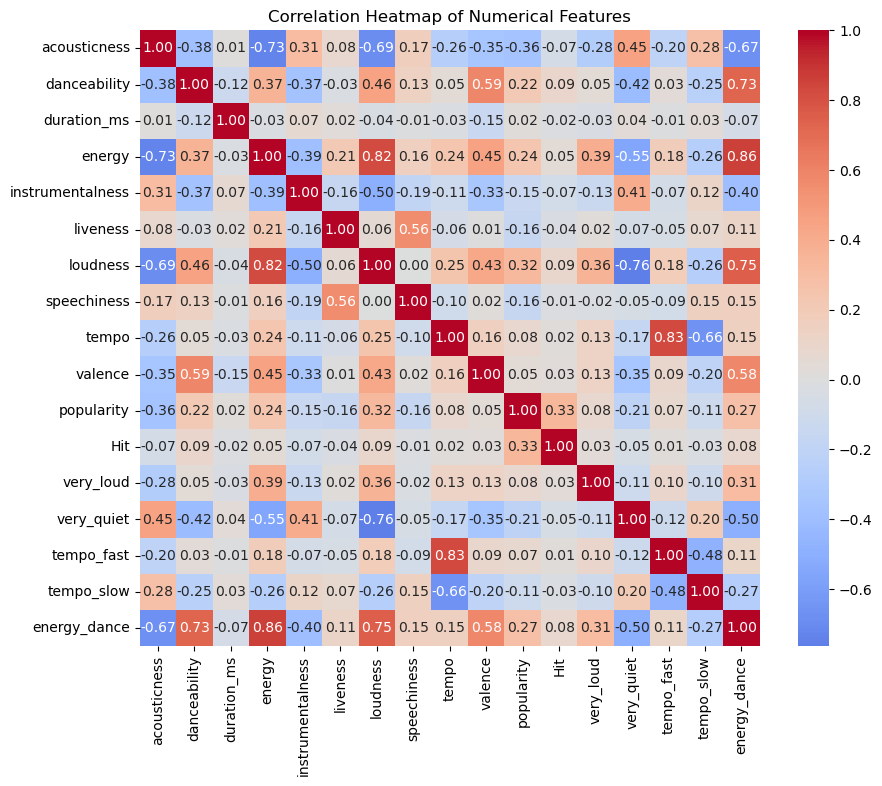

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

Several audio features such as energy, loudness, and danceability show moderate correlations
with popularity, suggesting they may be useful predictors.

### Independent and Dependent Variables

- **Dependent variable:** popularity 
- **Independent variables:** audio features such as energy, danceability, tempo, loudness, and duration

### 2.4: Perform exploratory analysis in combination with visualization techniques to discover patterns and features of interest

Exploratory analysis shows that hit songs tend to cluster around higher values of
danceability and energy, while extremely low popularity songs dominate the dataset.

### 2.5: Visualizations


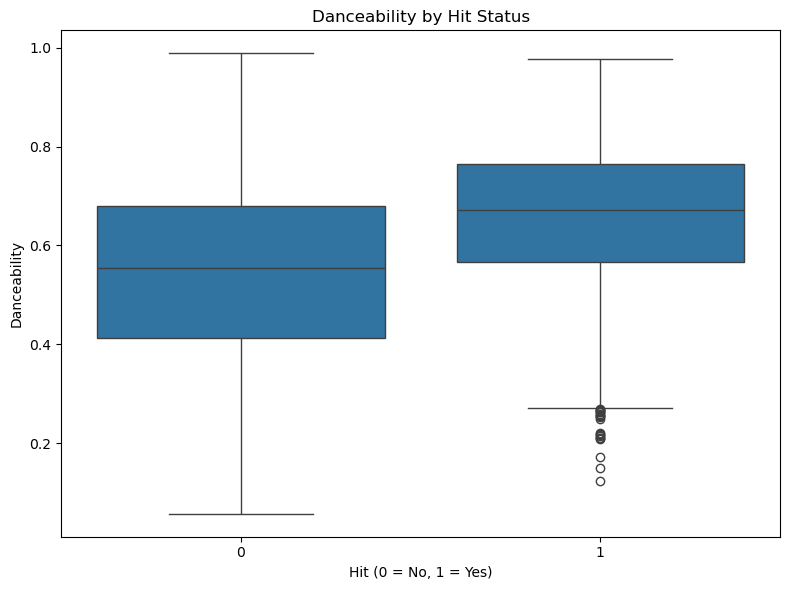

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(
    x="Hit",
    y="danceability",
    data=spotify
)

plt.title("Danceability by Hit Status")
plt.xlabel("Hit (0 = No, 1 = Yes)")
plt.ylabel("Danceability")
plt.tight_layout()
plt.show()

Hit songs tend to have higher energy and danceability than non hit songs, suggesting that these features are strongly associated with a song’s popularity.